# 1. Import Libraries and load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV
import joblib

# Converting to pandas dataframe
data = pd.read_excel('Production Data.xlsx',sheet_name='vw_ChurData')

#Display the first few rows
data.head()

,Customer_ID,Gender,Age,Married,Number_of_Dependents,City,Zip_Code,Latitude,Longitude,Number_of_Referrals,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827663,-118.999069,2,...,Credit Card,65.599998,593.299988,0.000000,0,381.510010,974.809998,Stayed,Others,Others
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162514,-118.203873,0,...,Credit Card,-4.000000,542.400024,38.330002,10,96.209999,610.280029,Stayed,Others,Others
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922615,0,...,Bank Withdrawal,73.900002,280.850006,0.000000,0,134.600006,415.450012,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014458,-122.115433,1,...,Bank Withdrawal,98.000000,1237.849976,0.000000,0,361.660004,1599.510010,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227844,-119.079903,3,...,Credit Card,83.900002,267.399994,0.000000,0,22.139999,289.540009,Churned,Dissatisfaction,Network reliability


# 2. Understanding Data

In [ ]:
data.shape

(6589, 38)

In [ ]:
data.columns

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'Number_of_Dependents',
       'City', 'Zip_Code', 'Latitude', 'Longitude', 'Number_of_Referrals',
       'Tenure_in_Months', 'Offer', 'Phone_Service',
       'Avg_Monthly_Long_Distance_Charges', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Avg_Monthly_GB_Download',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Tech_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6589 entries, 0 to 6588
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer_ID                        6589 non-null   object 
 1   Gender                             6589 non-null   object 
 2   Age                                6589 non-null   int64  
 3   Married                            6589 non-null   object 
 4   Number_of_Dependents               6589 non-null   int64  
 5   City                               6589 non-null   object 
 6   Zip_Code                           6589 non-null   int64  
 7   Latitude                           6589 non-null   float64
 8   Longitude                          6589 non-null   float64
 9   Number_of_Referrals                6589 non-null   int64  
 10  Tenure_in_Months                   6589 non-null   int64  
 11  Offer                              2991 non-null   objec

In [ ]:
data.describe()

,Age,Number_of_Dependents,Zip_Code,Latitude,Longitude,Number_of_Referrals,Tenure_in_Months,Avg_Monthly_Long_Distance_Charges,Avg_Monthly_GB_Download,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000,6589.000000
mean,46.760510,0.476097,93491.504477,36.199761,-119.757670,2.020944,34.499772,23.004277,20.876461,65.030695,2432.042244,2.080938,7.169525,798.087251,3235.218081
std,16.841362,0.968499,1857.575392,2.472459,2.155696,3.024016,23.968734,15.466844,20.406247,31.100727,2265.500081,8.125054,25.803163,853.767971,2854.600036
min,19.000000,0.000000,90001.000000,32.555828,-124.301369,0.000000,1.000000,0.000000,0.000000,-10.000000,18.850000,0.000000,0.000000,0.000000,21.610001
25%,33.000000,0.000000,92103.000000,33.989525,-121.788094,0.000000,12.000000,9.250000,4.000000,35.799999,544.549988,0.000000,0.000000,106.680000,835.450012
50%,46.000000,0.000000,93526.000000,36.245926,-119.601372,0.000000,32.000000,22.920000,17.000000,71.050003,1563.900024,0.000000,0.000000,472.679993,2376.449951
75%,60.000000,0.000000,95333.000000,38.169605,-117.967400,3.000000,57.000000,36.439999,27.000000,90.400002,4003.000000,0.000000,0.000000,1275.119995,5106.640137
max,80.000000,9.000000,96150.000000,41.962128,-114.192902,11.000000,72.000000,49.990002,85.000000,118.750000,8684.799805,49.790001,150.000000,3564.719971,11979.339844


# 3. Data Cleaning

In [ ]:
data.isnull().sum()

,0
Customer_ID,0
Gender,0
Age,0
Married,0
Number_of_Dependents,0
City,0
Zip_Code,0
Latitude,0
Longitude,0
Number_of_Referrals,0


In [ ]:
data["Internet_Type"] = data["Internet_Type"].replace("", "None")
data["Offer"] = data["Offer"].fillna("None")

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.dtypes

,0
Customer_ID,object
Gender,object
Age,int64
Married,object
Number_of_Dependents,int64
City,object
Zip_Code,int64
Latitude,float64
Longitude,float64
Number_of_Referrals,int64


In [ ]:
data["Customer_Status"].value_counts()

,count
Customer_Status,
Stayed,4720
Churned,1869


In [ ]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

# 3. Exploratory Data Analysis

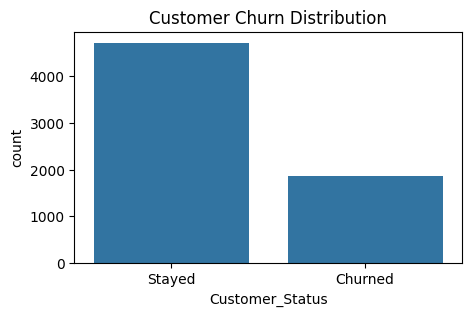

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x='Customer_Status',data=data)
plt.title('Customer Churn Distribution')
plt.show()

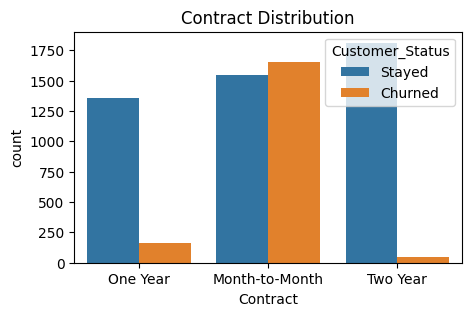

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x="Contract", hue = "Customer_Status", data=data)
plt.title('Contract Distribution')
plt.show()

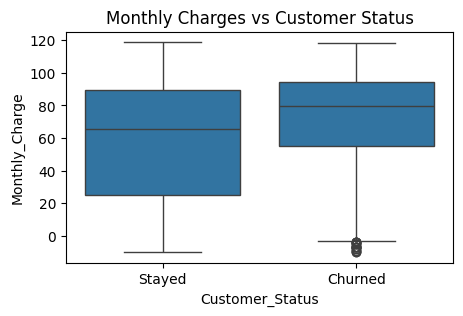

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x="Customer_Status", y="Monthly_Charge", data=data)
plt.title("Monthly Charges vs Customer Status")
plt.show()

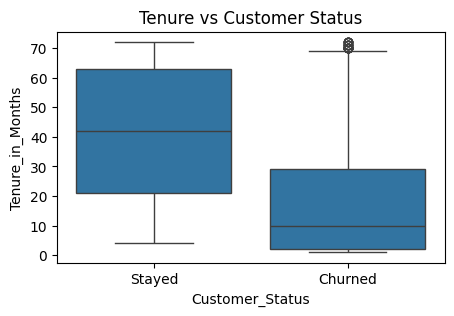

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x="Customer_Status", y="Tenure_in_Months", data=data)
plt.title("Tenure vs Customer Status")
plt.show()

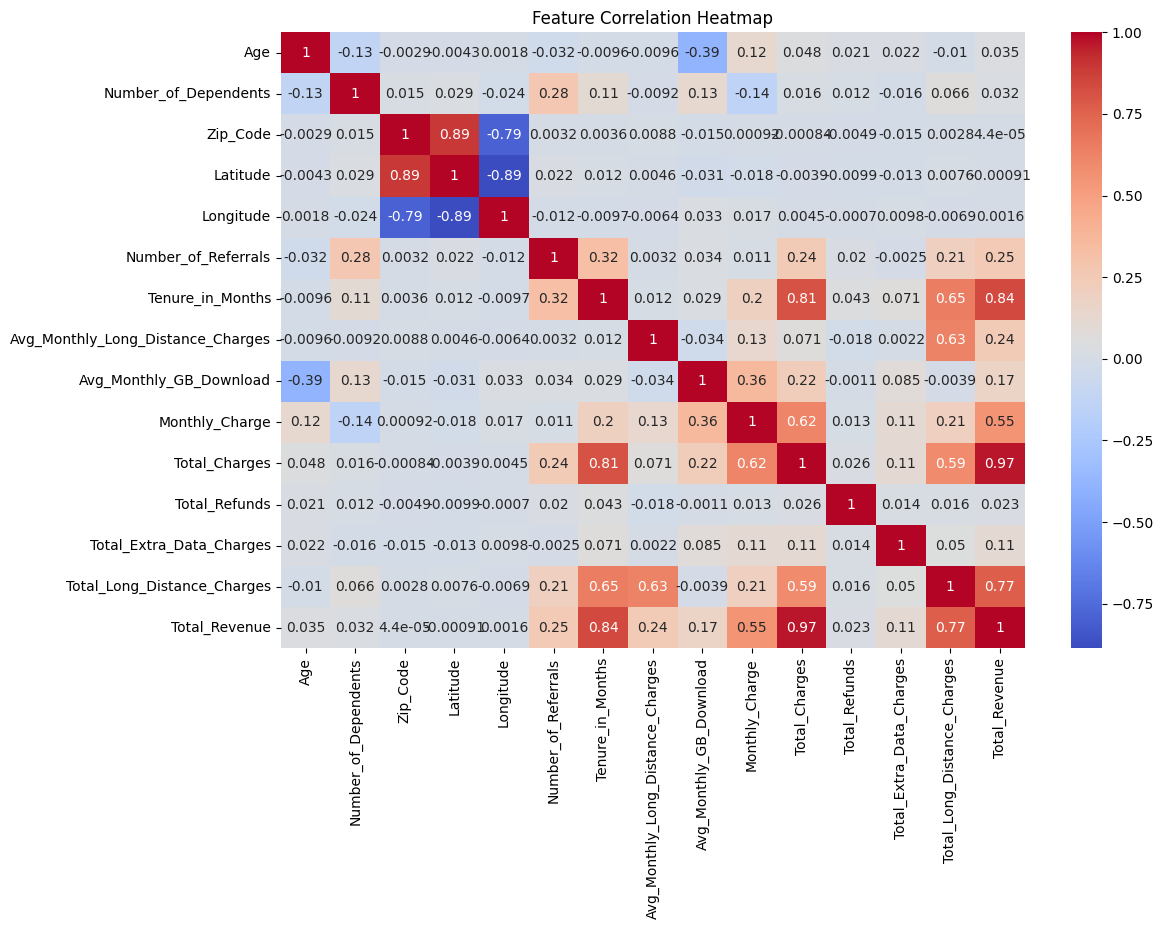

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data[num_cols].corr(), annot=True,cmap ='coolwarm')
plt.title("Feature Correlation Heatmap")
#plt.xticks(rotation=45)
#plt.yticks(rotation=45)
plt.show ()

# 4. Feature Selection

In [ ]:
drop_cols = [
    "Customer_ID",
    "Zip_Code",
    "Latitude",
    "Longitude",
    "Churn_Category",
    "Churn_Reason"
]

data = data.drop(columns=drop_cols)

In [ ]:
data.shape

(6589, 32)

# 5. Feature Engineering

In [ ]:
data["Tenure Group"]= pd.cut(data["Tenure_in_Months"], bins =[0,12,24,48,72,120],labels = ["0-1yr", "1-2yr", "2-4yr", "4-6yr", "6+yr"])

In [ ]:
# average spend per month
data["Revenue_Per_Month"] = data["Total_Revenue"] / (data["Tenure_in_Months"]+1)

In [ ]:
data[["Tenure Group","Revenue_Per_Month"]].head()

,Tenure Group,Revenue_Per_Month
0,0-1yr,97.481000
1,0-1yr,61.028003
2,0-1yr,83.090002
3,1-2yr,114.250715
4,0-1yr,72.385002


# 6. Data Preprocessing and Train-Test Split

In [ ]:
#columns to be label encoded
col_to_encode = ["Gender","Married","City","Offer","Phone_Service","Multiple_Lines",
    "Internet_Service","Internet_Type","Online_Security","Online_Backup",
    "Device_Protection_Plan","Premium_Tech_Support",
    "Streaming_TV","Streaming_Movies","Streaming_Music",
    "Unlimited_Data","Contract","Paperless_Billing", "Payment_Method","Tenure Group"]

# Handle 'Tenure Group' creation and NaN filling consistently
data["Tenure Group"]= pd.cut(data["Tenure_in_Months"], bins =[0,12,24,48,72,120],labels = ["0-1yr", "1-2yr", "2-4yr", "4-6yr", "6+yr"])
data["Tenure Group"] = data["Tenure Group"].astype(object).fillna("None")

# Encode cat cols except the target
label_encoders = {}
for column in col_to_encode:
  label_encoders[column] = LabelEncoder()
  # Ensure the column is of string type before fitting
  data[column] = data[column].astype(str)
  data[column] = label_encoders[column].fit_transform(data[column])


#Manually encoding target variable
data["Customer_Status"] = data["Customer_Status"].map({
    "Stayed": 0,
    "Churned": 1
})


#Split data into Feature and Target
X = data.drop("Customer_Status", axis=1)
y = data["Customer_Status"]

#Split data into training and test data set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(5271, 33)
(1318, 33)


# 7. Model Training

In [ ]:
#Define model
rf_model = RandomForestClassifier()

param_grid ={
    'n_estimators' : [ 100,150,175,200 ],
    'max_depth' : [ None,10,20 ],
    'min_samples_split' : [ 2,5,10 ],
    'max_features' : [ 'sqrt', 'log2' ]

}
# Grid Search with cross-validation
grid_search = GridSearchCV(rf_model, param_grid,cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)


Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 150}


In [ ]:
#Best paramenters from grid search
best_params = grid_search.best_params_

#Retran model with best parameters
best_rf = RandomForestClassifier(**best_params)
best_rf.fit(X_train, y_train)

RandomForestClassifier(max_features='log2', min_samples_split=10,
                       n_estimators=150)

# 8. Model Evaluation

In [ ]:
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred))

Accuracy: 0.8672230652503794
Confusion Matrix: [[892  43]
 [132 251]]
Classification Report:               precision    recall  f1-score   support

           0       0.87      0.95      0.91       935
           1       0.85      0.66      0.74       383

    accuracy                           0.87      1318
   macro avg       0.86      0.80      0.83      1318
weighted avg       0.87      0.87      0.86      1318



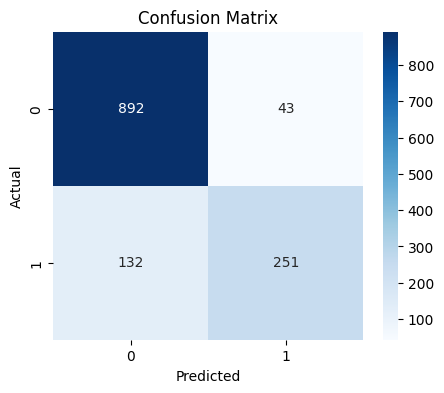

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 9. ROC-AUC Score and Curve

ROC-AUC Score: 0.9338936903980675


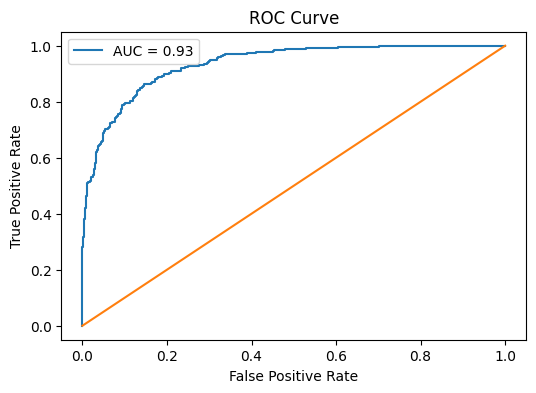

In [ ]:
y_prob = best_rf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# 10. Feature Importance

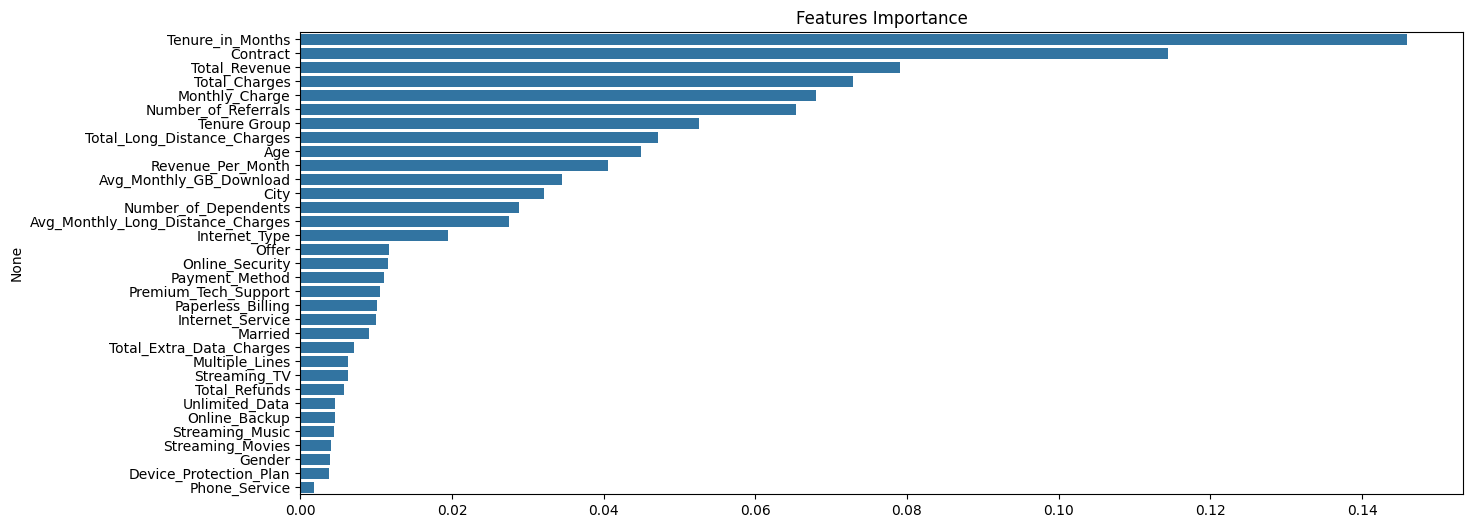

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
indices = importances.sort_values(ascending=False)

plt.figure(figsize=(15,6))
sns.barplot(x=indices.values, y=indices.index)
plt.title("Features Importance")
plt.show()

Insights from Feature Importance:

*   Customers with low tenure are more likely to churn.
*   Customers on month-to-month contracts have higher churn risk.
*   Higher monthly charges also contribute to churn probability.
*   Revenue and usage related features also influence customer retention.

# 11. Churn Prediction for New Customers

In [ ]:
#Read the data from specific sheet and covert into pandas df
new_data = pd.read_excel("Production Data.xlsx", sheet_name="vw_JoinData")
new_data.head()

,Customer_ID,Gender,Age,Married,Number_of_Dependents,City,Zip_Code,Latitude,Longitude,Number_of_Referrals,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,0021-IKXGC,Female,72,No,0,San Marcos,92078,33.119026,-117.166039,0,...,Bank Withdrawal,72.099998,72.099998,0.0,0,7.770000,79.870003,Joined,Others,Others
1,0030-FNXPP,Female,22,No,0,Keeler,93530,36.560497,-117.962463,0,...,Credit Card,19.850000,57.200001,0.0,0,9.360000,66.559998,Joined,Others,Others
2,0082-LDZUE,Male,54,No,0,Calistoga,94515,38.629620,-122.593216,0,...,Credit Card,44.299999,44.299999,0.0,0,42.950001,87.250000,Joined,Others,Others
3,0139-IVFJG,Female,19,Yes,0,Temecula,92592,33.507256,-117.029472,10,...,Bank Withdrawal,90.349998,190.500000,0.0,0,9.300000,199.800003,Joined,Others,Others
4,0178-CIIKR,Female,60,No,0,Crows Landing,95313,37.435665,-121.049057,0,...,Credit Card,19.950001,58.000000,0.0,0,8.070000,66.070000,Joined,Others,Others


In [ ]:
import pandas as pd

# Read new data
raw_new_data = pd.read_excel("Production Data.xlsx", sheet_name="vw_JoinData")
original_data = raw_new_data.copy()
new_data = raw_new_data.copy()

# Drop unused columns
new_data = new_data.drop(columns=drop_cols + ["Customer_Status"])

# Feature engineering
new_data["Tenure Group"] = pd.cut(
    new_data["Tenure_in_Months"],
    bins=[0,12,24,48,72,120],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr","6+yr"]
).astype(object).fillna("None")

new_data["Revenue_Per_Month"] = new_data["Total_Revenue"] / (new_data["Tenure_in_Months"] + 1)

# Handle NaNs and empty strings
for col in ["Internet_Type", "Offer"]:
    new_data[col] = new_data[col].astype(str).str.strip().replace("", "None").fillna("None")

# Encode using training encoders (do not fit again)
for column in col_to_encode:
    le = label_encoders[column]
    # map unseen categories to "None" first
    new_data[column] = new_data[column].astype(str).apply(lambda x: x if x in le.classes_ else "None")
    new_data[column] = le.transform(new_data[column])

# ---------------- Prediction with probability threshold ---------------- #

# Get predicted probability for Churned
pred_probs = best_rf.predict_proba(new_data)[:, 1]
threshold = 0.8
new_predictions = (pred_probs > threshold).astype(int)

# Add predictions to original dataframe
original_data["Customer_Status_Predicted"] = new_predictions

# Filter only Churned customers
ordinal_data = original_data[original_data["Customer_Status_Predicted"] == 1]

# Save results
ordinal_data.to_excel("Customer_Status_Predicted.xlsx", index=False)

# Optional: view how many predicted churn vs stayed
print("Predicted Churned:", ordinal_data.shape[0])
print("Predicted Stayed:", original_data.shape[0] - ordinal_data.shape[0])

Predicted Churned: 389
Predicted Stayed: 65


A probability threshold of 0.8 was used to classify churned customers, focusing on customers with higher churn risk.

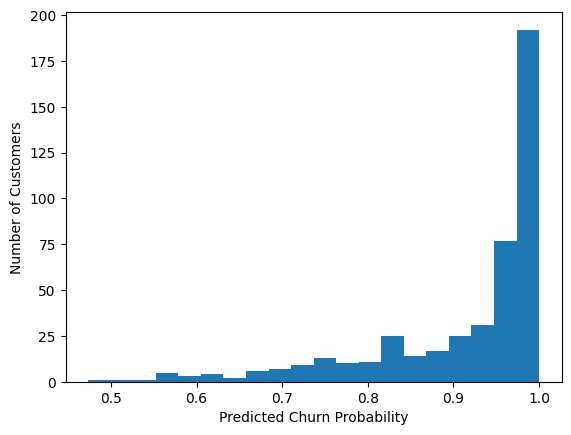

In [ ]:
pred_probs = best_rf.predict_proba(new_data)[:, 1]
import matplotlib.pyplot as plt
plt.hist(pred_probs, bins=20)
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.show()

# 12. Conclusion

This project developed a machine learning pipeline to predict customer churn using the Telco Customer Churn dataset.

The Random Forest model achieved strong performance with approximately 86% accuracy and a high ROC-AUC score.

Feature importance analysis shows that tenure, contract type, and revenue-related variables are key drivers of churn.

The trained model was further used to predict churn probabilities for new customers, enabling businesses to proactively identify high-risk customers and design retention strategies.